In [121]:
import os
import io
import sys
import cv2
import glob
import torch
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

In [122]:
PROJECT_PATH = "/Users/saratramontana/Documents/test_segmentation_model"
OVAMTA_PATH = "/Users/saratramontana/Documents/test_segmentation_model/external/OvaMTA"

sys.path.append(PROJECT_PATH)
sys.path.append(OVAMTA_PATH)

from new_data.data_loader import train_df, val_df

from lib.OvaMTA_seg import TransRaUNet_CLF_xiaorong as OvaSegModel
from lib.OvaMTA_diag import TransRaUNet_CLF_xiaorong as OvaDiagModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# print("Device:", device)
# print("Train df:", train_df.shape)
# print("Val df:", val_df.shape)
# print("Train labels:")
# print(train_df["risk_class"].value_counts())
# print("Val labels:")
# print(val_df["risk_class"].value_counts())

In [123]:
seg_ckpt_path = "/Users/saratramontana/Documents/test_segmentation_model/external/OvaMTA/test_ovamta_seg/uhod15jw/checkpoints/epoch=9-step=140.ckpt"
diag_ckpt_path = "/Users/saratramontana/Documents/test_segmentation_model/external/OvaMTA/test_ovamta_diag/gsb0nl9h/checkpoints/epoch=0-step=14.ckpt"

In [124]:
def load_lightning_checkpoint_into_ovamta(model, ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = ckpt["state_dict"]

    new_state_dict = {}

    for k, v in state_dict.items():
        if k.startswith("model."):
            new_key = k.replace("model.", "", 1)
            new_state_dict[new_key] = v

    model.load_state_dict(new_state_dict)
    model.to(device)
    model.eval()

    return model

In [125]:
os.chdir("/Users/saratramontana/Documents/test_segmentation_model/external/OvaMTA")

model_seg = OvaSegModel(training=False)
model_diag = OvaDiagModel(training=False)

model_seg = load_lightning_checkpoint_into_ovamta(model_seg, seg_ckpt_path, device)
model_diag = load_lightning_checkpoint_into_ovamta(model_diag, diag_ckpt_path, device)

print("Stage 1 OvaMTA-Seg loaded.")
print("Stage 2 OvaMTA-Diag loaded.")

Stage 1 OvaMTA-Seg loaded.
Stage 2 OvaMTA-Diag loaded.


In [126]:
TR_SIZE = 352

img_transform = transforms.Compose([
    transforms.Resize((TR_SIZE, TR_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [127]:
def predict_stage1_roi(image, model_seg, device, margin_352=10):
    orig_w, orig_h = image.size

    x = img_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        out5, out4, out3, out2, cls_out_seg, features = model_seg(x)

        res = out5 + out4 + out3 + out2

        # Come nella repo: threshold sui logits > 0
        mask_pred_352 = (res[0, 0] > 0).cpu().numpy().astype(np.uint8)

    contours, _ = cv2.findContours(
        mask_pred_352,
        cv2.RETR_EXTERNAL, #significa: prendi SOLO i contorni esterni
        cv2.CHAIN_APPROX_NONE #per mantenere tutti i punti del contorno 
    )

    if len(contours) == 0:
        x_min, y_min, x_max, y_max = 0, 0, orig_w, orig_h
        has_roi = False

    else:
        c = max(contours, key=cv2.contourArea)
        x_352, y_352, w_352, h_352 = cv2.boundingRect(c)

        x1_352 = max(0, x_352 - margin_352) #espando la box: più 10 pixel intorno 
        y1_352 = max(0, y_352 - margin_352)
        x2_352 = min(TR_SIZE, x_352 + w_352 + margin_352)
        y2_352 = min(TR_SIZE, y_352 + h_352 + margin_352)

        scale_x = orig_w / TR_SIZE
        scale_y = orig_h / TR_SIZE

        x_min = int(x1_352 * scale_x)
        y_min = int(y1_352 * scale_y)
        x_max = int(x2_352 * scale_x)
        y_max = int(y2_352 * scale_y)

        x_min = max(0, x_min) #evita bbx fuori immagine
        y_min = max(0, y_min)
        x_max = min(orig_w, x_max)
        y_max = min(orig_h, y_max)

        if x_max <= x_min or y_max <= y_min: #caso non valido bbox degenerata
            x_min, y_min, x_max, y_max = 0, 0, orig_w, orig_h
            has_roi = False
        else:
            has_roi = True

    return {
        "mask_pred_352": mask_pred_352,
        "bbox": (x_min, y_min, x_max, y_max),
        "has_roi": has_roi,
        "stage1_raw": cls_out_seg[0].detach().cpu().numpy() #cls_out_seg[0] prende la prima immagine del batch poichè x ha shape: [1,3,352,352] ed è un vettore di 3 logits logit_0, logit_1, logit_2
    }

In [128]:
def predict_stage2_diagnosis(image, bbox, model_diag, device, benign_threshold=0.65):
    x_min, y_min, x_max, y_max = bbox

    if x_max <= x_min or y_max <= y_min:
        x_min, y_min, x_max, y_max = 0, 0, image.size[0], image.size[1]

    patch = image.crop((x_min, y_min, x_max, y_max))

    x_patch = img_transform(patch).unsqueeze(0).to(device)

    with torch.no_grad():
        out5, out4, out3, out2, cls_out_diag, features = model_diag(x_patch)

    # logits (come nella repo)
    raw = cls_out_diag[0].detach().cpu().numpy()

    p_benign_raw = float(raw[0])
    p_malignant_raw = float(raw[1])

    # SOGLIA COME NELLA REPO
    if p_benign_raw > benign_threshold:
        pred_label = 0
        pred_class = "benign"
    else:
        pred_label = 1
        pred_class = "malignant"

    # opzionale (solo per logging)
    probs = torch.softmax(cls_out_diag, dim=1)[0].detach().cpu().numpy()

    return {
        "patch": patch,
        "stage2_raw": raw,
        "stage2_softmax": probs,
        "p_benign_raw": p_benign_raw,
        "p_malignant_raw": p_malignant_raw,
        "prob_benign_softmax": float(probs[0]),
        "prob_malignant_softmax": float(probs[1]),
        "pred_label": pred_label,
        "pred_class": pred_class
    }

In [129]:
def ovamta_inference_one_row(row, model_seg, model_diag, device):
    image = Image.open(io.BytesIO(row["image"])).convert("RGB")

    stage1 = predict_stage1_roi(
        image=image,
        model_seg=model_seg,
        device=device,
        margin_352=10
    )

    stage2 = predict_stage2_diagnosis(
        image=image,
        bbox=stage1["bbox"],
        model_diag=model_diag,
        device=device,
        benign_threshold=0.65
    )

    true_label = int(row["risk_class"])

    return {
        "image": image,
        "mask_pred_352": stage1["mask_pred_352"],
        "bbox": stage1["bbox"],
        "has_roi": stage1["has_roi"],
        "stage1_raw": stage1["stage1_raw"],

        "patch": stage2["patch"],
        "stage2_raw": stage2["stage2_raw"],
        "stage2_softmax": stage2["stage2_softmax"],
        "p_benign_raw": stage2["p_benign_raw"],
        "p_malignant_raw": stage2["p_malignant_raw"],
        "prob_benign_softmax": stage2["prob_benign_softmax"],
        "prob_malignant_softmax": stage2["prob_malignant_softmax"],
        "pred_label": stage2["pred_label"],
        "pred_class": stage2["pred_class"],

        "true_label": true_label,
        "true_class": "malignant" if true_label == 1 else "benign"
    }

In [130]:
idx = 0
row = val_df.iloc[idx]

result = ovamta_inference_one_row(
    row=row,
    model_seg=model_seg,
    model_diag=model_diag,
    device=device
)

print("True:", result["true_label"], result["true_class"])
print("Pred:", result["pred_label"], result["pred_class"])
print("BBox:", result["bbox"])
print("Has ROI:", result["has_roi"])
print("Stage 1 raw [ovary, benign, malignant]:", result["stage1_raw"])
print("Stage 2 raw [benign, malignant]:", result["stage2_raw"])
print("Stage 2 softmax:", result["stage2_softmax"])

True: 1 malignant
Pred: 1 malignant
BBox: (17, 59, 201, 207)
Has ROI: True
Stage 1 raw [ovary, benign, malignant]: [0.00376589 0.00287487 0.99854255]
Stage 2 raw [benign, malignant]: [0.18576613 0.7187204 ]
Stage 2 softmax: [0.36982813 0.6301719 ]


In [131]:
print(result["stage2_raw"])

[0.18576613 0.7187204 ]


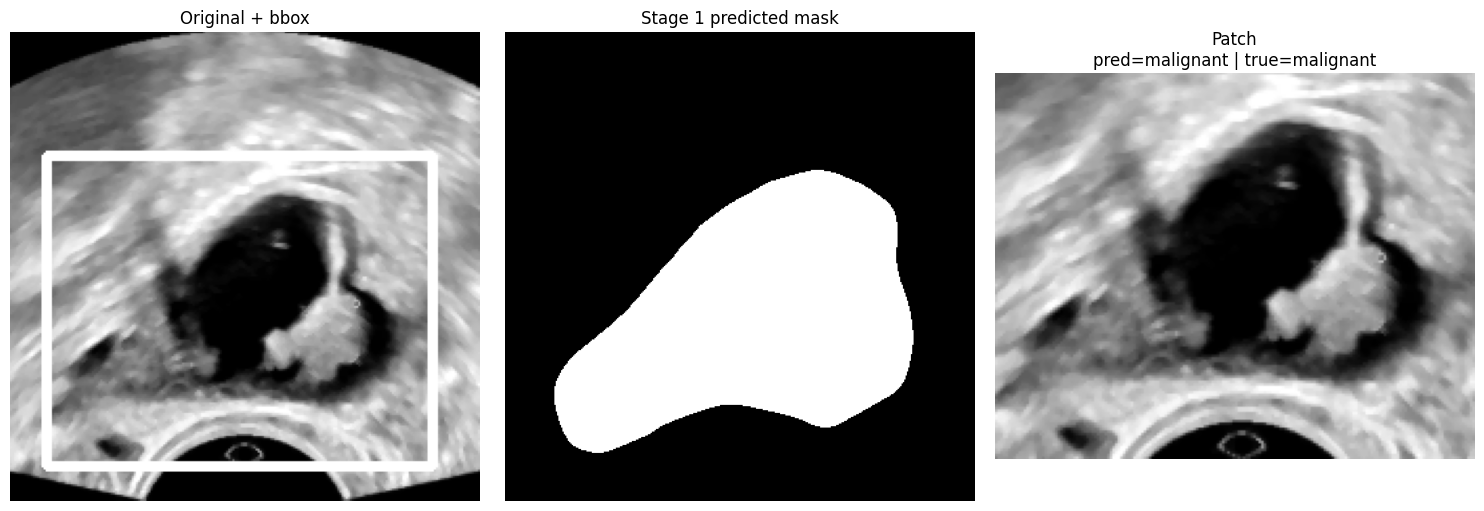

In [132]:
def show_inference_result(result):
    image_np = np.array(result["image"])
    x_min, y_min, x_max, y_max = result["bbox"]

    image_box = image_np.copy()

    cv2.rectangle(
        image_box,
        (x_min, y_min),
        (x_max, y_max),
        color=(255, 255, 255),
        thickness=3
    )

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image_box)
    plt.title("Original + bbox")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(result["mask_pred_352"], cmap="gray")
    plt.title("Stage 1 predicted mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(result["patch"])
    plt.title(
        f"Patch\npred={result['pred_class']} | true={result['true_class']}"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_inference_result(result)

In [133]:
all_results = []

for idx in range(len(val_df)):
    row = val_df.iloc[idx]

    result = ovamta_inference_one_row(
        row=row,
        model_seg=model_seg,
        model_diag=model_diag,
        device=device
    )

    all_results.append({
        "idx": idx,
        "true_label": result["true_label"],
        "true_class": result["true_class"],
        "pred_label": result["pred_label"],
        "pred_class": result["pred_class"],
        "has_roi": result["has_roi"],
        "bbox": result["bbox"],
        "p_benign_raw": result["p_benign_raw"],
        "p_malignant_raw": result["p_malignant_raw"],
        "prob_benign_softmax": result["prob_benign_softmax"],
        "prob_malignant_softmax": result["prob_malignant_softmax"],
        "stage1_raw": result["stage1_raw"],
        "stage2_raw": result["stage2_raw"],
    })

results_df = pd.DataFrame(all_results)
results_df.head()

,idx,true_label,true_class,pred_label,pred_class,has_roi,bbox,p_benign_raw,p_malignant_raw,prob_benign_softmax,prob_malignant_softmax,stage1_raw,stage2_raw
0,0,1,malignant,1,malignant,True,"(17, 59, 201, 207)",0.185766,0.718720,0.369828,0.630172,"[0.0037658932, 0.0028748699, 0.99854255]","[0.18576613, 0.7187204]"
1,1,1,malignant,1,malignant,True,"(24, 71, 188, 194)",0.185579,0.718383,0.369863,0.630137,"[0.004519342, 0.0042125983, 0.9978109]","[0.1855788, 0.7183833]"
2,2,1,malignant,1,malignant,True,"(21, 10, 199, 201)",0.185429,0.718686,0.369757,0.630243,"[0.004403419, 0.28838116, 0.70783764]","[0.18542868, 0.7186861]"
3,3,1,malignant,1,malignant,True,"(37, 17, 224, 204)",0.185417,0.718675,0.369757,0.630243,"[0.003965612, 0.38781166, 0.5417494]","[0.18541664, 0.7186748]"
4,4,1,malignant,1,malignant,True,"(56, 76, 199, 207)",0.185434,0.718682,0.369760,0.630240,"[0.003310693, 0.0027075885, 0.9977659]","[0.1854342, 0.7186822]"


In [134]:
accuracy = (results_df["true_label"] == results_df["pred_label"]).mean()
print("Validation accuracy:", accuracy)

pd.crosstab(
    results_df["true_class"],
    results_df["pred_class"],
    rownames=["True"],
    colnames=["Pred"]
)

Validation accuracy: 0.9117647058823529


Pred,malignant
True,
benign,6
malignant,62


In [135]:
results_df.to_csv("ovamta_inference_results_val.csv", index=False)
print("Saved: ovamta_inference_results_val.csv")

Saved: ovamta_inference_results_val.csv
